---
title: "Differential Beer-Lambert plume retrieval from the LUT"
---

# Beer–Lambert forward model & differential plume-enhancement retrieval

This notebook closes the loop between the offline-generated CH$_4$ cross-section LUT (notebook 01) and the plume-simulation sub-project. The LUT's job is to make the runtime forward model fast — ~1 ms per pixel instead of ~1 s for a direct line-by-line call. The forward model's job is to simulate the **transmittance ratio** $\tau_{\mathrm{plume}}(\nu) / \tau_{\mathrm{bg}}(\nu)$ that a satellite spectrometer measures when looking at a plume pixel vs a nearby background pixel. The retrieval's job is to invert that ratio for the column enhancement $\varepsilon$.

Structure:
1. **Load the LUT** built in notebook 01, verify it against a direct HAPI call.
2. **Single-layer forward model** — compute $\tau(\nu)$ at background VMR.
3. **Differential Beer–Lambert** — build $\tau_{\mathrm{enh}}(\nu; \varepsilon)$ for a menu of $\varepsilon$ values.
4. **Tie to `gauss_plume`** — take a synthetic plume from `simulate_plume`, convert its column enhancement to a VMR enhancement, and build the corresponding measured-ratio spectrum.
5. **Retrieve $\varepsilon$** from a noisy simulated ratio via least squares, pixel by pixel.

See [00_hapi_lut_derivation.md](00_hapi_lut_derivation.md) for the physics and [01_hapi_lut_ch4.ipynb](01_hapi_lut_ch4.ipynb) for the LUT build.

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from plume_simulation.gauss_plume import simulate_plume
from plume_simulation.hapi_lut import (
    ATMOSPHERIC_GASES,
    beers_law_from_lut,
    number_density,
    plume_ratio_spectrum,
)
from plume_simulation.hapi_lut.beers import ATM_TO_PA, BOLTZMANN_J_PER_K

rng = np.random.default_rng(0)

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pixi.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
LUT_PATH = REPO_ROOT / "projects" / "plume_simulation" / "data" / "hapi_lut" / "ch4_absorption_lut.nc"
assert LUT_PATH.exists(), f"Run 01_hapi_lut_ch4.ipynb first — missing {LUT_PATH}"

ch4_lut = xr.open_dataset(LUT_PATH)
ch4_lut

<xarray.Dataset> Size: 520kB
Dimensions:                   (wavenumber: 10000, temperature: 3, pressure: 3)
Coordinates:
  * wavenumber                (wavenumber) float64 80kB 4e+03 4e+03 ... 4.5e+03
    wavelength                (wavenumber) float64 80kB ...
  * temperature               (temperature) float64 24B 220.0 260.0 300.0
  * pressure                  (pressure) float64 24B 0.3 0.6 1.0
Data variables:
    absorption_cross_section  (wavenumber, temperature, pressure) float32 360kB ...
Attributes: (12/14)
    title:                CH4 Absorption Cross-Section Look-Up Table
    institution:          Generated using HITRAN API (HAPI)
    source:               HITRAN molecular spectroscopic database
    molecule:             CH4
    molecule_id:          6
    isotopologue_id:      1
    ...                   ...
    temperature_range_K:  220-300
    pressure_range_atm:   0.30-1.00
    line_shape:           Voigt profile
    description:          Methane — primary greenhouse-gas retrieval target.
    conventions:          CF-1.8
    creation_date:        2026-04-23T11:02:41.379237+00:00

## 1. Reference atmosphere and geometry

Mid-troposphere state: $T = 260$ K, $p = 0.6$ atm. The mapping from viewing geometry to the two-way AMF follows the plane-parallel formula
$\mathrm{AMF} = 1/\cos \mathrm{SZA} + 1/\cos \mathrm{VZA}$.
At nadir ($\mathrm{SZA} = \mathrm{VZA} = 0$) this is exactly 2.

In [2]:
T_K = 260.0
p_atm = 0.6
SZA_deg = 30.0
VZA_deg = 0.0   # nadir-looking
L_vert_cm = 8e5  # 8 km tropospheric column

# Background CH4 mixing ratio: ~1.9 ppm (current global mean).
VMR_BG = 1.9e-6

## 2. Single-layer forward transmittance

`beers_law_from_lut` chains:
- $\sigma(\nu) \leftarrow$ bilinear interp of the LUT at $(T, p)$,
- $\alpha(\nu) = \sigma(\nu) \cdot N_{\mathrm{CH_4}}$ with $N_{\mathrm{CH_4}} = \mathrm{VMR} \cdot p/(k_B T)$,
- $\tau(\nu) = \exp(-\alpha \cdot L_{\mathrm{vert}} \cdot \mathrm{AMF})$.

At background VMR the methane $\nu_3$ band produces ~5 % dips in the clearest lines.

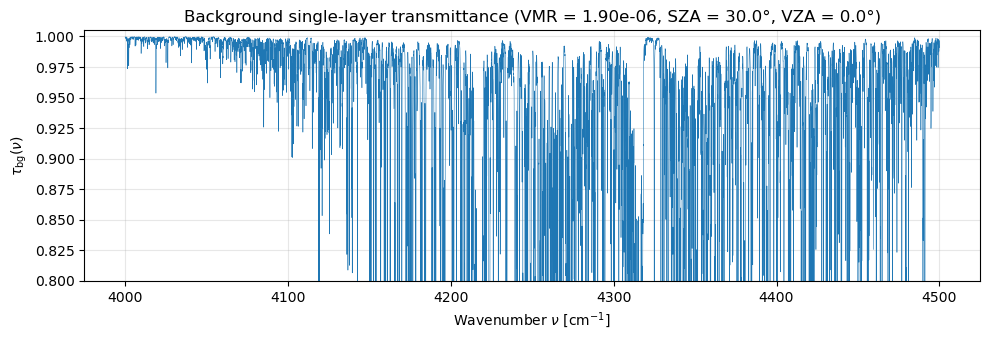

In [3]:
tau_bg = beers_law_from_lut(
    ch4_lut,
    vmr=VMR_BG, T_K=T_K, p_atm=p_atm,
    l_vert_cm=L_vert_cm, sza_deg=SZA_deg, vza_deg=VZA_deg,
)

fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(tau_bg["wavenumber"], tau_bg, lw=0.4, color="C0")
ax.set_xlabel(r"Wavenumber $\nu$ [cm$^{-1}$]")
ax.set_ylabel(r"$\tau_{\mathrm{bg}}(\nu)$")
ax.set_title(rf"Background single-layer transmittance (VMR = {VMR_BG:.2e}, SZA = {SZA_deg}°, VZA = {VZA_deg}°)")
ax.set_ylim(0.8, 1.005)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Differential Beer–Lambert: $\tau_{\mathrm{enh}}$ vs $\varepsilon$

The key physics (§5 of the derivation note) is that dividing a plume pixel's transmittance by a nearby background pixel's transmittance cancels out the solar spectrum, surface albedo, aerosol, and target-gas background — leaving only the *narrow-band* enhancement signature

$$\tau_{\mathrm{enh}}(\nu;\varepsilon) \;=\; \frac{\tau(\nu; (1+\varepsilon)\,\mathrm{VMR}_{\mathrm{bg}})}{\tau(\nu; \mathrm{VMR}_{\mathrm{bg}})}.$$

We build a menu of such ratios for $\varepsilon \in \{0, 5 \%, 10 \%, 20 \%\}$.

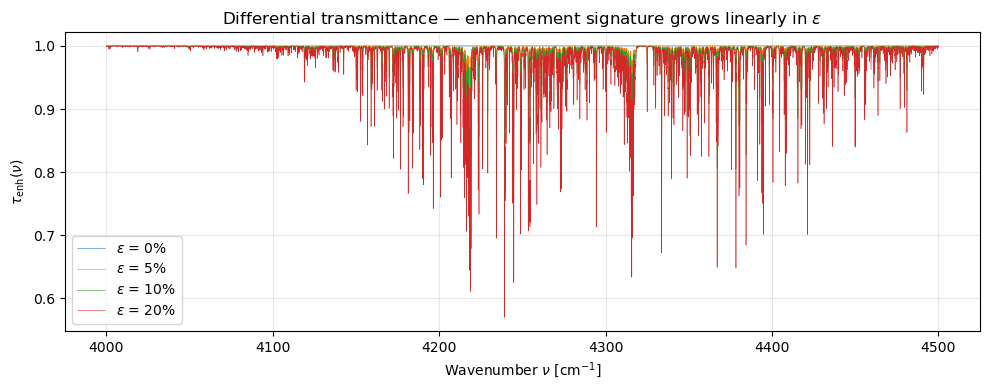

In [4]:
enhancements = [0.00, 0.05, 0.10, 0.20]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for eps in enhancements:
    ratio = plume_ratio_spectrum(
        ch4_lut,
        vmr_background=VMR_BG,
        vmr_total=(1.0 + eps) * VMR_BG,
        T_K=T_K, p_atm=p_atm,
        l_vert_cm=L_vert_cm, sza_deg=SZA_deg, vza_deg=VZA_deg,
    )
    ax.plot(ratio["wavenumber"], ratio, lw=0.4, label=rf"$\varepsilon$ = {eps*100:.0f}%")
ax.set_xlabel(r"Wavenumber $\nu$ [cm$^{-1}$]")
ax.set_ylabel(r"$\tau_{\mathrm{enh}}(\nu)$")
ax.set_title(r"Differential transmittance — enhancement signature grows linearly in $\varepsilon$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The depth of the absorption signature scales roughly linearly with $\varepsilon$ in the small-enhancement regime — that's the regime where classical matched-filter retrievals have a closed-form MLE.

## 4. Tie in the Gaussian plume — column enhancement → VMR enhancement

Use the steady-state Gaussian plume forward model to get column CH$_4$ enhancement [kg/m²] over a 2-D ground footprint. Emission: $Q = 500$ kg/hr from a ground-level source, wind 5 m/s from the west (meteo convention: `wind_direction = 270°`), neutral stability (class D).

In [5]:
Q_kg_per_s = 500.0 / 3600.0
plume_ds = simulate_plume(
    emission_rate=Q_kg_per_s,
    source_location=(0.0, 0.0, 2.0),
    wind_speed=5.0,
    wind_direction=270.0,
    stability_class="D",
    domain_x=(-200.0, 1200.0, 141),
    domain_y=(-400.0, 400.0, 81),
    domain_z=(0.0, 100.0, 21),
)
col_ch4 = plume_ds["column_concentration"]  # [kg/m²], shape (x, y)
print(f"column CH4 enhancement range: [{float(col_ch4.min()):.2e}, {float(col_ch4.max()):.2e}] kg/m²")

column CH4 enhancement range: [0.00e+00, 6.73e-03] kg/m²


### 4a. Column → VMR mapping

The **background CH$_4$ column mass density** follows from the hydrostatic air column $p_{\mathrm{surf}} / g$ and the CH$_4$ mass fraction $\mathrm{VMR}_{\mathrm{bg}} \cdot M_{\mathrm{CH_4}} / M_{\mathrm{air}}$:

$$C_{\mathrm{bg}}^{\mathrm{CH_4}} \;=\; \frac{p_{\mathrm{surf}}}{g} \cdot \mathrm{VMR}_{\mathrm{bg}} \cdot \frac{M_{\mathrm{CH_4}}}{M_{\mathrm{air}}}.$$

The fractional enhancement is then $\varepsilon(x, y) = C_{\mathrm{plume}}(x, y) / C_{\mathrm{bg}}^{\mathrm{CH_4}}$.

In [6]:
M_CH4 = 16.04e-3   # kg/mol
M_AIR = 28.97e-3   # kg/mol
G_MS2 = 9.81       # m/s²
P_SURF_PA = 101325.0

air_column_kg_m2 = P_SURF_PA / G_MS2
ch4_bg_column_kg_m2 = air_column_kg_m2 * VMR_BG * (M_CH4 / M_AIR)
print(f"air column:       {air_column_kg_m2:.0f} kg/m²")
print(f"CH4 bg column:    {ch4_bg_column_kg_m2*1e3:.3f} g/m² (VMR_bg = {VMR_BG:.2e})")

eps_field = (col_ch4 / ch4_bg_column_kg_m2).values  # shape (n_x, n_y)
print(f"peak ε:           {eps_field.max()*100:.2f}%")

air column:       10329 kg/m²
CH4 bg column:    10.866 g/m² (VMR_bg = 1.90e-06)
peak ε:           61.90%


### 4b. Synthetic scene — ε(x, y) footprint

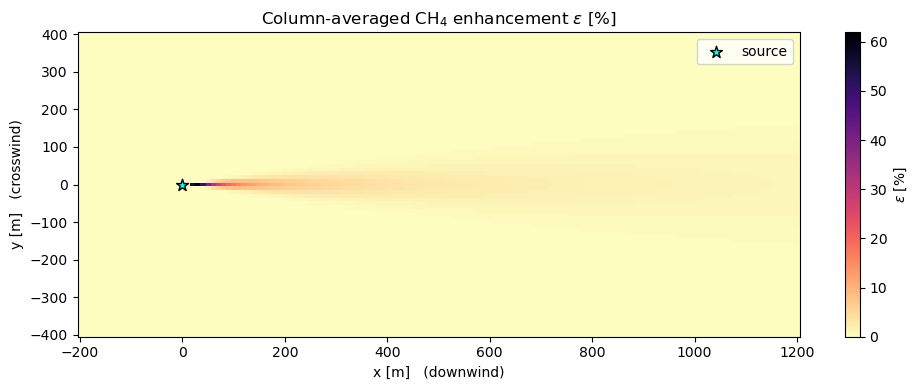

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
im = ax.pcolormesh(
    plume_ds["x"], plume_ds["y"], eps_field.T * 100,
    cmap="magma_r", vmin=0.0, vmax=float(eps_field.max()) * 100,
    shading="auto",
)
ax.set_xlabel("x [m]   (downwind)")
ax.set_ylabel("y [m]   (crosswind)")
ax.set_title("Column-averaged CH$_4$ enhancement $\\varepsilon$ [%]")
ax.scatter([0], [0], s=80, marker="*", color="cyan", edgecolor="k", label="source")
ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, label=r"$\varepsilon$ [%]")
plt.tight_layout()
plt.show()

## 5. Per-pixel differential retrieval

We now retrieve $\hat\varepsilon$ from a simulated noisy ratio spectrum at each pixel. Forward model for the simulated ratio at pixel $(x, y)$ with true enhancement $\varepsilon_{\mathrm{true}}$:

$$I_{\mathrm{meas}}(\nu) \;=\; \tau_{\mathrm{enh}}(\nu; \varepsilon_{\mathrm{true}}) + \eta(\nu), \qquad \eta \sim \mathcal{N}(0, \sigma_n^2).$$

Taking the log linearises the problem: in the small-enhancement limit $\log \tau_{\mathrm{enh}}(\nu; \varepsilon) \approx \varepsilon \cdot \log \tau_{\mathrm{enh}}(\nu; 1.0)$, so the MLE is a single closed-form projection (matched filter):

$$\hat\varepsilon \;=\; \frac{\langle \log I_{\mathrm{meas}}, \,K \rangle}{\|K\|^2}, \qquad K(\nu) \;:=\; \log \tau_{\mathrm{enh}}(\nu; 1.0).$$

This is the matched-filter kernel used in operational retrievals (Thompson et al., Thorpe et al.). Below we precompute $K$ once from the LUT and project every pixel's synthetic noisy log-ratio onto it.

In [8]:
# Precompute the kernel K from the LUT.
# We use a pinned reference enhancement ε_ref = 1% and rescale.
# (Rescaling avoids numerical overflow from the direct ε=1.0 call which
# can produce τ → 0 in strong lines.)
eps_ref = 0.01
K_full = np.log(
    plume_ratio_spectrum(
        ch4_lut, vmr_background=VMR_BG, vmr_total=(1.0 + eps_ref) * VMR_BG,
        T_K=T_K, p_atm=p_atm, l_vert_cm=L_vert_cm, sza_deg=SZA_deg, vza_deg=VZA_deg,
    ).values
) / eps_ref

# Restrict the fit to the strong-absorption portion of the band (4150–4400 cm^-1)
# where the matched-filter SNR is highest.
nu = ch4_lut["wavenumber"].values
fit_mask = (nu >= 4150.0) & (nu <= 4400.0)
K = K_full[fit_mask]
print(f"kernel support: {K.size} pts over {nu[fit_mask].min():.0f}-{nu[fit_mask].max():.0f} cm^-1")


def retrieve_eps(eps_true: float, noise_sigma: float) -> float:
    """One-shot synthetic retrieval — build τ_enh at ε_true, add noise, project."""
    tau_true = plume_ratio_spectrum(
        ch4_lut, vmr_background=VMR_BG, vmr_total=(1.0 + eps_true) * VMR_BG,
        T_K=T_K, p_atm=p_atm, l_vert_cm=L_vert_cm, sza_deg=SZA_deg, vza_deg=VZA_deg,
    ).values[fit_mask]
    # Measurement = multiplicative noise on the ratio (constant relative error).
    noisy = tau_true * np.exp(rng.normal(0.0, noise_sigma, size=tau_true.size))
    y = np.log(noisy)
    return float(np.dot(y, K) / np.dot(K, K))

kernel support: 5000 pts over 4150-4400 cm^-1


### 5a. Single-pixel smoke test

In [9]:
eps_true = 0.10
eps_hat = retrieve_eps(eps_true, noise_sigma=0.003)
print(f"ε_true = {eps_true*100:.2f}%   ε_hat = {eps_hat*100:.3f}%")

ε_true = 10.00%   ε_hat = 10.002%


### 5b. Retrieval sweep across the plume

We downsample the 2-D footprint to a coarser retrieval grid (every 5th x-pixel × every 5th y-pixel) to keep wallclock reasonable, then plot $\hat\varepsilon$ vs $\varepsilon_{\mathrm{true}}$ on a scatter diagram.

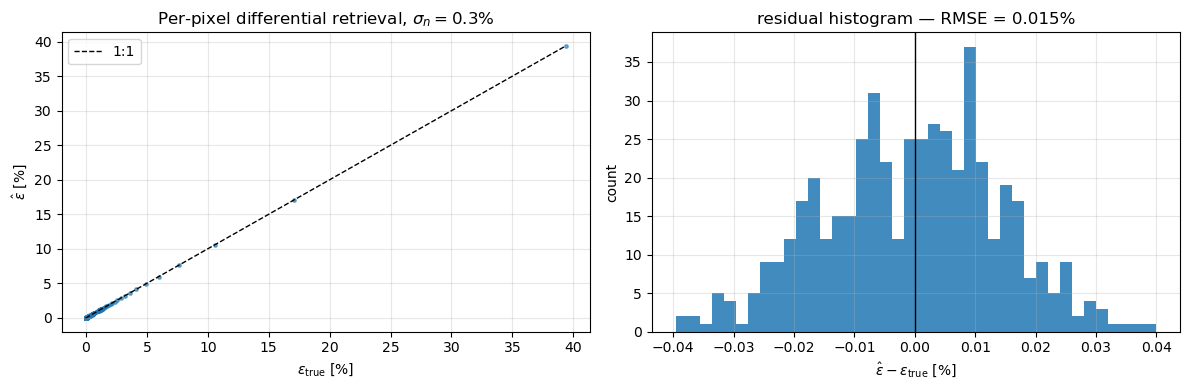

retrieval bias:  -0.0006%
retrieval RMSE:  0.0145%
retrieval N:     493 pixels


In [10]:
sub = eps_field[::5, ::5]
eps_true_flat = sub.ravel()

noise_sigma = 0.003  # 0.3% multiplicative noise on the τ ratio
eps_hat_flat = np.array([retrieve_eps(eps, noise_sigma) for eps in eps_true_flat])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes

ax1.scatter(eps_true_flat * 100, eps_hat_flat * 100, s=6, alpha=0.6)
eps_min = float(min(eps_true_flat.min(), eps_hat_flat.min())) * 100
eps_max = float(max(eps_true_flat.max(), eps_hat_flat.max())) * 100
ax1.plot([eps_min, eps_max], [eps_min, eps_max], "k--", lw=1, label="1:1")
ax1.set_xlabel(r"$\varepsilon_{\mathrm{true}}$ [%]")
ax1.set_ylabel(r"$\hat\varepsilon$ [%]")
ax1.set_title(r"Per-pixel differential retrieval, $\sigma_n = 0.3\%$")
ax1.legend()
ax1.grid(alpha=0.3)

residuals = (eps_hat_flat - eps_true_flat) * 100
ax2.hist(residuals, bins=40, color="C0", alpha=0.85)
ax2.axvline(0, color="k", lw=1)
ax2.set_xlabel(r"$\hat\varepsilon - \varepsilon_{\mathrm{true}}$ [%]")
ax2.set_ylabel("count")
ax2.set_title(rf"residual histogram — RMSE = {residuals.std():.3f}%")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"retrieval bias:  {residuals.mean():+.4f}%")
print(f"retrieval RMSE:  {residuals.std():.4f}%")
print(f"retrieval N:     {residuals.size} pixels")

## 6. Takeaways

- The LUT lets us evaluate $\tau(\nu)$ at arbitrary $(T, p, \mathrm{VMR})$ in ~1 ms per pixel — fast enough for per-pixel retrievals over full satellite scenes.
- The **differential** form $\tau_{\mathrm{enh}} = \tau_{\mathrm{total}} / \tau_{\mathrm{bg}}$ cancels every nuisance factor that is common to the plume and the reference pixel. The matched filter exploits this to retrieve $\varepsilon$ linearly in the small-enhancement regime.
- Coupling to `gauss_plume` gives us a physics-consistent synthetic scene: the column-enhancement field from the Gaussian plume provides the "truth" $\varepsilon_{\mathrm{true}}(x, y)$, which the LUT-driven retrieval then reconstructs from a simulated spectrometer measurement.

Next directions (not implemented here):

- **Layered atmospheres.** Replace the single-layer AMF with a per-layer VOD sum. The LUT stays the same; the forward model sums transmittances layer-wise.
- **Instrument spectral response.** Convolve $\tau_{\mathrm{enh}}$ with an ISRF before the retrieval to match a specific sensor's bandpass.
- **Joint gas retrieval.** Extend $K$ to a matrix with columns for CH$_4$, H$_2$O, CO$_2$ enhancements and use the combined LUT from notebook 02.
- **Optimal estimation.** The matched filter is the MLE in the small-enhancement linear limit; adding a Gaussian prior gives the Rodgers optimal-estimation form with posterior covariance.